In [23]:
import os, re
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

from datetime import datetime
import math
import pandas as pd
from itertools import chain

from utils import post_process_get_moving_test_data_and_timestamp
from utils import remove_outlier_by_quantile
from static_data_processing import get_test_files_and_survey
from plot_utils import *

from pandas.core.common import SettingWithCopyWarning
import warnings
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)
pd.set_option('display.max_rows', None)
ROOT_DIR = os.path.join("C:/Users/wangz/OneDrive/University_RU/NSUWB/")
CALIBRATED_CAM_TO_V2B = -6400.8
pd.set_option('display.float_format', lambda x: '%.5f' % x)

RESAMPLE_RULE = "1S"

TEST_FILE_NAME = "2021-05-25-11-13-08-moving-v2-4-west-12mph"

In [24]:
test_file_list, ground_truth_list = post_process_get_moving_test_data_and_timestamp(ROOT_DIR, "Moving Test 1 (V2V)", "V2", CALIBRATED_CAM_TO_V2B)
assert(len(test_file_list) == len(ground_truth_list))
for i in range(len(test_file_list)):
    test_file, ground_truth = test_file_list[i], ground_truth_list[i]
    if "data-A-user-processed_log" in test_file and os.path.basename(test_file).startswith("2021"):
        continue
    if TEST_FILE_NAME in test_file:
        _test_csv_base = "PostProcessed_" + os.path.splitext(os.path.basename(test_file))[0] + ".csv"
        _integ_csv_base = "Integrated_ABAB_COMBO-" + _test_csv_base.split("PostProcessed_")[1].split("-data-")[0] + ".csv"
        _integ_csv_dir = os.path.join(os.path.dirname(test_file), _integ_csv_base)
        fdir = _integ_csv_dir
        df = pd.read_csv(fdir, parse_dates=["Datetime Normalized"], index_col=["Datetime Normalized"])
        moving_ground_truth_df = ground_truth
        static_veh = 1
        moving_veh = 2
        break

static_main_master = '0C1A'
static_focusing_slaves = ['1912', '8D38']
static_master_slave_mapping = { '0C1A': [static_focusing_slaves[0], static_focusing_slaves[1]],
                        '9B0F': [static_focusing_slaves[1], static_focusing_slaves[0]]}
moving_main_master = '88BA'
moving_focusing_slaves = ['45BA', '0B8A']
moving_master_slave_mapping = { '88BA': [moving_focusing_slaves[0], moving_focusing_slaves[1]],
                        '111C': [moving_focusing_slaves[1], moving_focusing_slaves[0]]}

In [25]:
df["Aggregated Update Rate (Hz)"] = np.nan
df['UWB Measured Speed - Strict Pair (mph)'] = np.nan
# Remove duplicated index
_newindex = df.reset_index().groupby("Datetime Normalized")["Datetime Normalized"].apply(lambda x: x + np.arange(x.size).astype(np.timedelta64))
df.index = _newindex

if moving_ground_truth_df is None:
    time_stamp_lim = [df.index.min(),df.index.max()]
else:
    min_time = min(df.index.min(), pd.to_datetime(moving_ground_truth_df["Time UNIX Norm (s)"],unit='s').min())
    max_time = max(df.index.max(), pd.to_datetime(moving_ground_truth_df["Time UNIX Norm (s)"],unit='s').max())
    time_stamp_lim = [min_time, max_time]

df_static_veh_all_pairs = df[df['Initiating Vehicle'] == static_veh]
df_moving_veh_all_pairs = df[df['Initiating Vehicle'] == moving_veh]
df_static_veh_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)
df_moving_veh_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)

df_static_veh_hz_aggregated_all_pairs = update_rate_by_strict_pairs(        df_static_veh_all_pairs, 
                                                                            static_master_slave_mapping.keys(), 
                                                                            static_focusing_slaves)
df_moving_veh_hz_aggregated_all_pairs = update_rate_by_strict_pairs(        df_moving_veh_all_pairs, 
                                                                            moving_master_slave_mapping.keys(), 
                                                                            moving_focusing_slaves)
df_static_veh_hz_aggregated_all_pairs = instant_spd_by_strict_pairs(        df_static_veh_hz_aggregated_all_pairs, 
                                                                            static_master_slave_mapping.keys(), 
                                                                            static_focusing_slaves)
df_moving_veh_hz_aggregated_all_pairs = instant_spd_by_strict_pairs(        df_moving_veh_hz_aggregated_all_pairs, 
                                                                            moving_master_slave_mapping.keys(), 
                                                                            moving_focusing_slaves)
df_static_veh_hz_aggregated_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)
df_moving_veh_hz_aggregated_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)

In [37]:
def get_nan_slices_indices(df, veh, time_stamp_lim):
    slices = []
    _flag = False
    
    for i in range(len(df['Aggregated Update Rate (Hz)'])):
        if not np.isnan(df.iloc[i]['Aggregated Update Rate (Hz)']):
            if _flag == True:
                if slices:
                    slices[-1].append(df.iloc[i]["Datetime Normalized"])
                    _flag = not _flag
        else:
            if _flag == False:
                if 0 < i-1 < len(df['Aggregated Update Rate (Hz)']) - 1:
                    slices.append([df.iloc[i-1]["Datetime Normalized"]])
                    _flag = not _flag
                if 0 == i:
                    slices.append([df.iloc[i]["Datetime Normalized"]])
                    _flag = not _flag
                if len(df['Aggregated Update Rate (Hz)']) - 1 == i:
                    if slices:
                        slices[-1].append(df.iloc[i]["Datetime Normalized"])
    if slices:
        print(slices)
        _nan_start, _nan_stop = slices[0][0], slices[-1][-1]
        if df[(df["Datetime Normalized"] < _nan_start) & (df["Datetime Normalized"] > df[df['Initiating Vehicle']==veh]["Datetime Normalized"].min())]['Aggregated Update Rate (Hz)'].size <= 1:
            slices.insert(0, [time_stamp_lim[0], _nan_start])
        if df[(df["Datetime Normalized"] > _nan_stop) & (df["Datetime Normalized"] < df[df['Initiating Vehicle']==veh]["Datetime Normalized"].max())]['Aggregated Update Rate (Hz)'].size <= 1:
            slices.append([_nan_stop, time_stamp_lim[1]])
    else:
        _nan_start, _nan_stop = df["Datetime Normalized"].min(), df["Datetime Normalized"].max()
        slices.insert(0, [min(time_stamp_lim[0], _nan_start), max(time_stamp_lim[0], _nan_start)])
        slices.append([min(time_stamp_lim[1], _nan_stop), max(time_stamp_lim[1], _nan_stop)])
    import itertools
    slices.sort()
    print(list(k for k,_ in itertools.groupby(slices)))
    return list(k for k,_ in itertools.groupby(slices))

[[Timestamp('2021-05-25 11:13:13'), Timestamp('2021-05-25 11:13:14')]]
[[Timestamp('2021-05-25 11:13:13'), Timestamp('2021-05-25 11:13:14')], [Timestamp('2021-05-25 11:13:13.428440064'), Timestamp('2021-05-25 11:13:13')]]


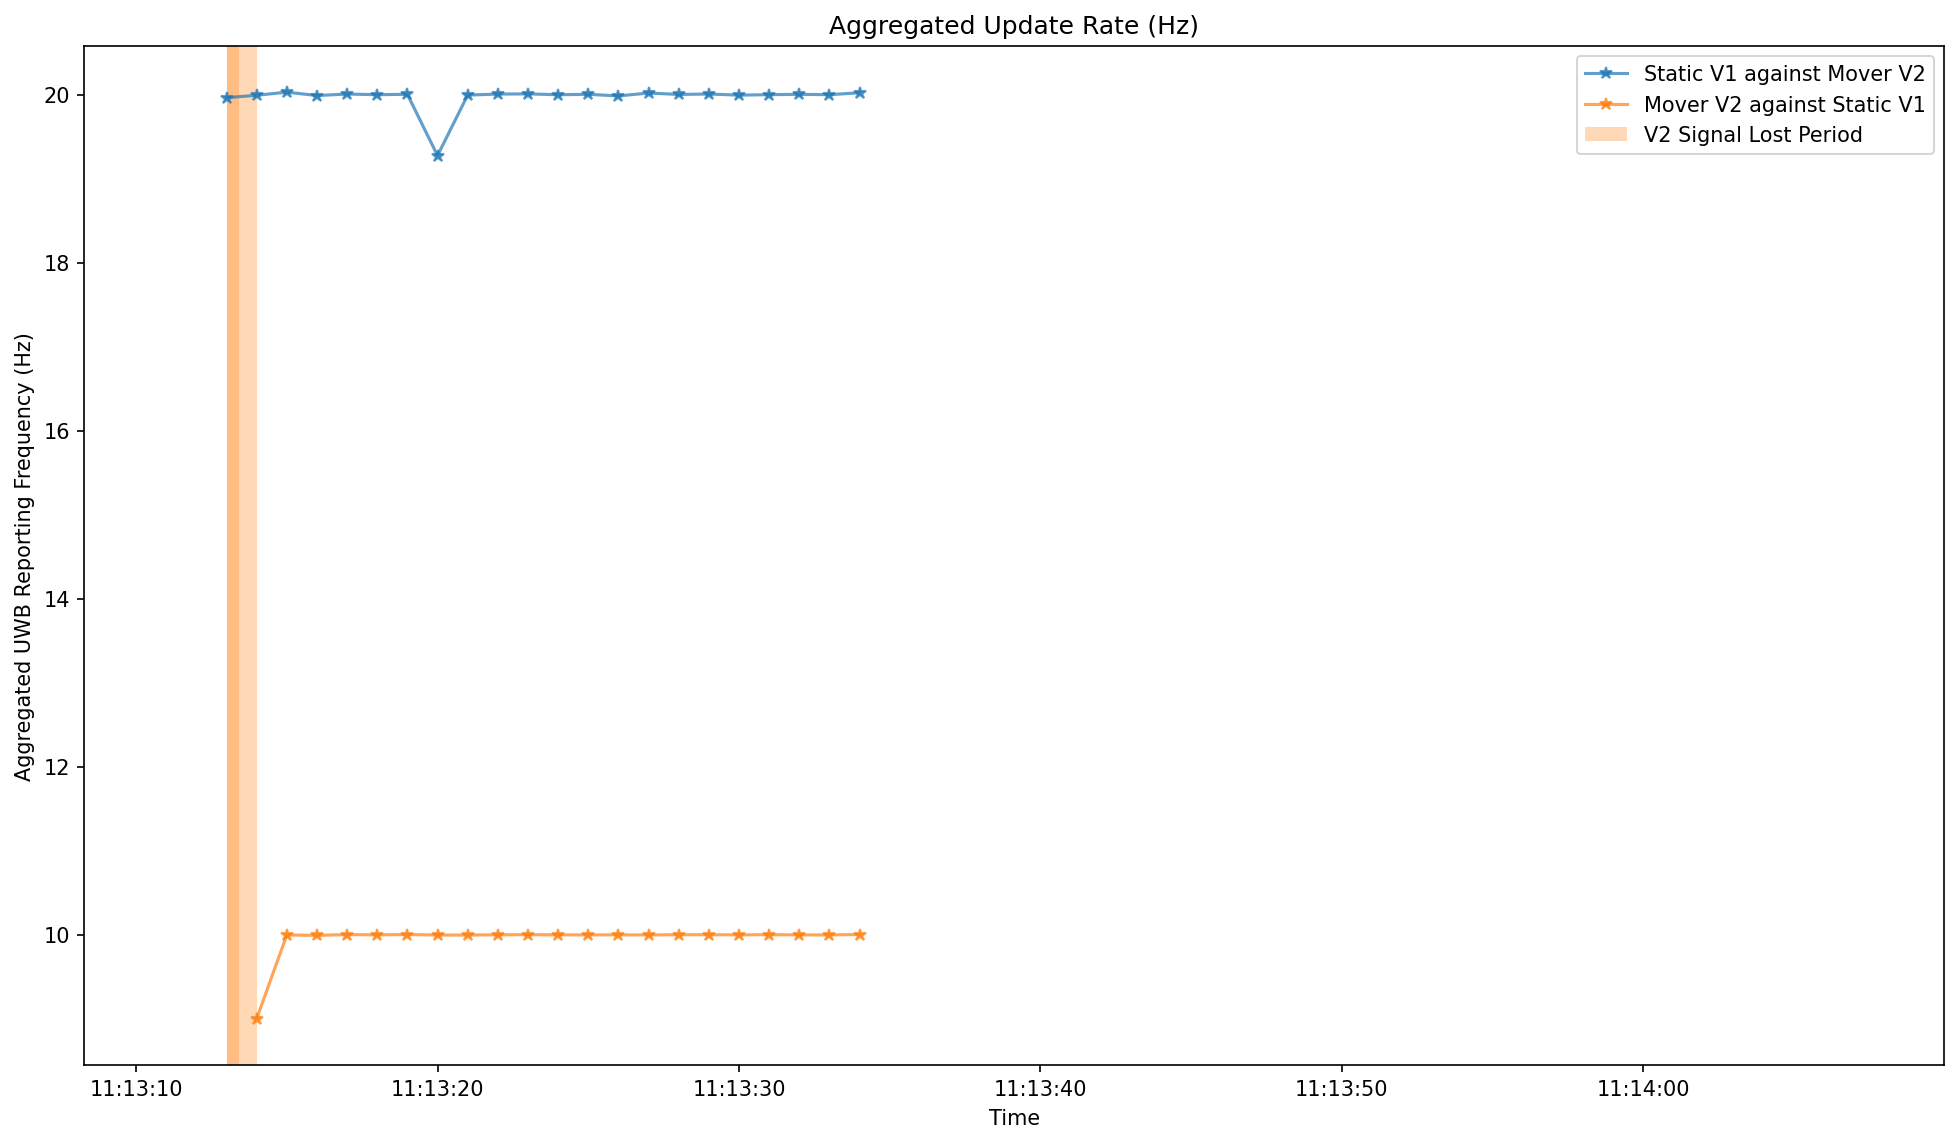

In [39]:
figure = plt.figure(figsize=(16, 9), dpi=150)
ax = figure.add_subplot(111)
static_veh_df = df_static_veh_hz_aggregated_all_pairs.resample(rule=RESAMPLE_RULE).mean()
moving_veh_df = df_moving_veh_hz_aggregated_all_pairs.resample(rule=RESAMPLE_RULE).mean()
ax.plot(static_veh_df.index, 
        static_veh_df["Aggregated Update Rate (Hz)"], 
        label="Static V{} against Mover V{}".format(static_veh, moving_veh),
        alpha=0.7,
        color='C0',
        marker="*")
ax.plot(moving_veh_df.index, 
        moving_veh_df["Aggregated Update Rate (Hz)"], 
        label="Mover V{} against Static V{}".format(moving_veh, static_veh),
        alpha=0.7,
        color='C1',
        marker="*")

ax.set_title("Aggregated Update Rate (Hz)")
ax.set_xlabel("Time")
_time_span = time_stamp_lim[1] - time_stamp_lim[0]
_xlim = [time_stamp_lim[0] - 0.1 * _time_span, time_stamp_lim[1] + 0.1 * _time_span]
ax.set_xlim(_xlim)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.set_ylabel("Aggregated UWB Reporting Frequency (Hz)")

# Span for missing values
reindexed_static = static_veh_df.reset_index()
reindexed_moving = moving_veh_df.reset_index()
# static_nan_slices = get_nan_slices_indices(reindexed_static, veh=static_veh, time_stamp_lim=time_stamp_lim)
# for i in range(len(static_nan_slices)):
#     slice = static_nan_slices[i]
#     if len(slice) < 2:
#         continue
#     [slice_lo, slice_hi] = slice
#     ax.axvspan( slice_lo, slice_hi,
#                 facecolor='C0',
#                 alpha=0.3,
#                 label="_" * i + "V{} Signal Lost Period".format(static_veh))

moving_nan_slices = get_nan_slices_indices(reindexed_moving, veh=moving_veh, time_stamp_lim=time_stamp_lim)
for i in range(len(moving_nan_slices)):
    slice = moving_nan_slices[i]
    if len(slice) < 2:
        continue
    [slice_lo, slice_hi] = slice
    ax.axvspan( slice_lo, slice_hi,
                facecolor='C1',
                alpha=0.3,
                label="_" * i + "V{} Signal Lost Period".format(moving_veh))
ax.legend()

In [36]:
moving_nan_slices

[[Timestamp('2021-05-25 11:13:13'), Timestamp('2021-05-25 11:13:14')],
 [Timestamp('2021-05-25 11:13:13.428440064'),
  Timestamp('2021-05-25 11:13:13')]]

In [40]:
moving_veh_df

,Reporting Master X (mm),Reporting Master Y (mm),Reporting Master Z (mm),Initiating Vehicle,Initiating Vehicle Length (mm),Reporting Slave X (mm),Reporting Slave Y (mm),Reporting Slave Z (mm),Reporting Vehicle,Reporting Vehicle Length (mm),Correction Distance (mm),UWB Distance (mm),Surveyed Distance (mm),Timestamp Norm (s),Timestamp Local (s),Instant Update Rate (Hz),Aggregated Update Rate (Hz),UWB Measured Speed - Strict Pair (mph)
Datetime Normalized,,,,,,,,,,,,,,,,,,
2021-05-25 11:13:13,2400.00000,-1470.00000,1890.00000,2.00000,12140.00000,11670.00000,1070.00000,2980.00000,1.00000,15500.00000,276.25000,7069.75000,NaN,1621941193.63072,1621941192.47438,7.68276,NaN,0.62786
2021-05-25 11:13:14,2400.00000,-1470.00000,1890.00000,2.00000,12140.00000,11670.00000,1070.00000,2980.00000,1.00000,15500.00000,336.70000,7125.10000,NaN,1621941194.48078,1621941193.32444,10.01027,9.00129,0.07990
2021-05-25 11:13:15,2400.00000,-1470.00000,1890.00000,2.00000,12140.00000,11670.00000,1070.00000,2980.00000,1.00000,15500.00000,354.90000,7142.10000,NaN,1621941195.48092,1621941194.32458,9.99673,9.99827,-0.20473
2021-05-25 11:13:16,2400.00000,-1470.00000,1890.00000,2.00000,12140.00000,11670.00000,1070.00000,2980.00000,1.00000,15500.00000,292.90000,7084.80000,NaN,1621941196.48136,1621941195.32502,9.99412,9.99406,-0.02529
2021-05-25 11:13:17,2400.00000,-1470.00000,1890.00000,2.00000,12140.00000,11670.00000,1070.00000,2980.00000,1.00000,15500.00000,252.70000,7047.90000,NaN,1621941197.48128,1621941196.32494,10.00047,10.00277,-0.03337
2021-05-25 11:13:18,2400.00000,-1470.00000,1890.00000,2.00000,12140.00000,11670.00000,1070.00000,2980.00000,1.00000,15500.00000,327.10000,7116.30000,NaN,1621941198.48127,1621941197.32493,10.00590,9.99973,0.17121
2021-05-25 11:13:19,2400.00000,-1470.00000,1890.00000,2.00000,12140.00000,11670.00000,1070.00000,2980.00000,1.00000,15500.00000,312.90000,7103.20000,NaN,1621941199.48128,1621941198.32494,10.00057,10.00325,0.03504
2021-05-25 11:13:20,2400.00000,-1470.00000,1890.00000,2.00000,12140.00000,11670.00000,1070.00000,2980.00000,1.00000,15500.00000,303.80000,7094.90000,NaN,1621941200.48117,1621941199.32483,10.00362,9.99773,-0.11273
2021-05-25 11:13:21,2400.00000,-1470.00000,1890.00000,2.00000,12140.00000,11670.00000,1070.00000,2980.00000,1.00000,15500.00000,297.30000,7088.90000,NaN,1621941201.48133,1621941200.32500,9.98994,9.99771,0.03545
